<div style="
    background: linear-gradient(135deg, #E8F3F5, #F7FBFC);
    border-left: 6px solid #2F6F7E;
    border-radius: 12px;
    padding: 20px;
    margin: 10px 0 20px 0;
">

<h1 style="color:#234F5C; margin-bottom:8px;">
Week 6 - Day 5
</h1>

<h2 style="color:#2F6F7E; margin-top:0;">
Neural Network Tuning, Evaluation & Sprint Review
</h2>

<p style="color:#3F4A52; line-height:1.7; font-size:15px;">
In this notebook, I will tune the neural network systematically by changing
one hyperparameter at a time. I will compare the experiments using validation
loss, apply EarlyStopping and ModelCheckpoint, and evaluate the best model
against the previous models and the Logistic Regression baseline.
</p>

<p style="color:#3F4A52; line-height:1.7; font-size:15px;">
Finally, I will summarize the Sprint 1 results and write a short retrospective
with one concrete improvement for Sprint 2.
</p>

</div>

<div style="
    background:#F6F9FA;
    border-radius:10px;
    padding:14px 16px;
    margin:14px 0;
    border-left:5px solid #2F6F7E;
">

<h2 style="color:#2F6F7E; margin:0 0 8px 0;">
Step 1 - Import the Required Libraries
</h2>

<p style="color:#3F4A52; margin:0; line-height:1.6;">
Import the tools required for data preparation, neural network tuning,
callbacks, evaluation, and visualization.
</p>

</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

tf.keras.utils.set_random_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from sklearn.impute import SimpleImputer

<div style="
    background:#FDF2F8;
    border-left:5px solid #DB2777;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h2 style="color:#BE185D;margin:0 0 7px 0;">
Step 2 - Load the Same Project Dataset
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The same Heart Failure Prediction Dataset and preprocessing settings from Day 4
will be reused to ensure that all tuning experiments are compared fairly.
</p>

</div>

In [4]:
data_path = "../heart.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())

df.head()

Dataset shape: (918, 12)

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<div style="
    background:#EFF6FF;
    border-left:5px solid #2563EB;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h2 style="color:#1D4ED8;margin:0 0 7px 0;">
Step 3 - Clean and Split the Data
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Invalid zero measurements will be replaced with missing values.
The same stratified 80/20 split and random state from Day 4 will be reused
to keep the final comparison fair.
</p>

</div>

In [5]:
# Keep the original dataset unchanged
df_clean = df.copy()

# Zero is medically invalid for these measurements
df_clean[["Cholesterol", "RestingBP"]] = (
    df_clean[["Cholesterol", "RestingBP"]]
    .replace(0, np.nan)
)

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training positive rate:", round(y_train.mean(), 3))
print("Testing positive rate:", round(y_test.mean(), 3))

Training shape: (734, 11)
Testing shape: (184, 11)
Training positive rate: 0.553
Testing positive rate: 0.554


<div style="
    background:#F5F3FF;
    border-left:5px solid #7C3AED;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h3 style="color:#6D28D9;margin:0 0 7px 0;">
Step 3.1 - Preprocess the Features
</h3>

<p style="color:#475569;line-height:1.8;margin:0;">
Missing numerical measurements will be filled using the training median,
numerical features will be standardized, and categorical features will be
converted into numerical columns using One-Hot Encoding.
</p>

</div>

In [6]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

# Learn preprocessing rules from training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the learned rules to the untouched test data
X_test_processed = preprocessor.transform(X_test)

# Convert the arrays to the format preferred by Keras
X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

y_train_nn = y_train.to_numpy(dtype="float32")
y_test_nn = y_test.to_numpy(dtype="float32")

print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Remaining missing values:", np.isnan(X_train_processed).sum())

Original features: 11
Processed features: 21
Processed training shape: (734, 21)
Processed testing shape: (184, 21)
Remaining missing values: 0


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h3 style="color:#047857;margin:0 0 7px 0;">
Step 3.2 - Create the Validation Set
</h3>

<p style="color:#475569;line-height:1.8;margin:0;">
A stratified validation set will be separated from the training data.
It will be used to compare the tuning experiments, while the test set
remains untouched until the final evaluation.
</p>

</div>

In [7]:
X_nn_train, X_val, y_nn_train, y_val = train_test_split(
    X_train_processed,
    y_train_nn,
    test_size=0.20,
    stratify=y_train_nn,
    random_state=42
)

print("Neural-network training shape:", X_nn_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test_processed.shape)

Neural-network training shape: (587, 21)
Validation shape: (147, 21)
Test shape: (184, 21)


<div style="
    background:linear-gradient(135deg,#312E81 0%,#6D28D9 60%,#BE185D 100%);
    border-radius:16px;
    padding:21px 23px;
    margin:24px 0 16px 0;
">

<p style="color:#FBCFE8;font-weight:bold;letter-spacing:1.2px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 1
</p>

<h2 style="color:#FFFFFF;margin:0 0 9px 0;">
Systematic Neural Network Tuning
</h2>

<p style="color:#EDE9FE;line-height:1.8;margin:0;">
I will tune the learning rate, network size, dropout rate, and batch size.
Only one hyperparameter will change at each stage so that the effect of
every change can be interpreted clearly.
</p>

</div>

In [8]:
def build_tuned_model(
    learning_rate=0.001,
    hidden_units=(16, 8),
    dropout_rate=0.30
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = Sequential([
        Input(shape=(X_nn_train.shape[1],)),

        Dense(
            hidden_units[0],
            activation="relu",
            name="hidden_layer_1"
        ),

        BatchNormalization(
            name="batch_normalization"
        ),

        Dropout(
            dropout_rate,
            name="dropout_layer"
        ),

        Dense(
            hidden_units[1],
            activation="relu",
            name="hidden_layer_2"
        ),

        Dense(
            1,
            activation="sigmoid",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Model-building function is ready.")

Model-building function is ready.


<div style="
    background:#EFF6FF;
    border-left:5px solid #2563EB;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#2563EB;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
TUNING PRIORITY 1
</p>

<h2 style="color:#1E3A8A;margin:0 0 9px 0;">
Learning Rate Experiments
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Three learning rates will be tested while the architecture, dropout rate,
batch size, training data, and number of epochs remain fixed.
The experiment with the lowest validation loss will be selected.
</p>

</div>

In [9]:
learning_rate_values = [
    0.01,
    0.001,
    0.0001
]

learning_rate_results = []
learning_rate_histories = {}

for learning_rate in learning_rate_values:
    print(f"Training with learning rate = {learning_rate}")

    model = build_tuned_model(
        learning_rate=learning_rate,
        hidden_units=(16, 8),
        dropout_rate=0.30
    )

    history = model.fit(
        X_nn_train,
        y_nn_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    best_index = int(
        np.argmin(history.history["val_loss"])
    )

    learning_rate_results.append({
        "Learning Rate": learning_rate,
        "Best Epoch": best_index + 1,
        "Best Validation Loss":
            history.history["val_loss"][best_index],
        "Validation Accuracy":
            history.history["val_accuracy"][best_index]
    })

    learning_rate_histories[learning_rate] = history

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
).sort_values(
    by="Best Validation Loss"
).reset_index(drop=True)

learning_rate_results_df.round(4)

Training with learning rate = 0.01

Training with learning rate = 0.001
Training with learning rate = 0.0001


,Learning Rate,Best Epoch,Best Validation Loss,Validation Accuracy
0,0.0100,9,0.4103,0.8435
1,0.0010,48,0.4384,0.8299
2,0.0001,50,0.6391,0.5646


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 20px 0;
">

<h3 style="color:#047857;margin:0 0 9px 0;">
Learning Rate Observation
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The learning rate of
<b style="color:#7C3AED;">0.01</b>
achieved the lowest validation loss of
<b style="color:#059669;">0.4103</b>
at epoch 9, with a validation accuracy of
<b style="color:#2563EB;">84.35%</b>.

The learning rate of 0.001 learned more slowly and reached a higher minimum loss,
while 0.0001 was too slow within the 50-epoch training budget.

Therefore, 0.01 will be carried forward to the next tuning stage.
</p>

</div>

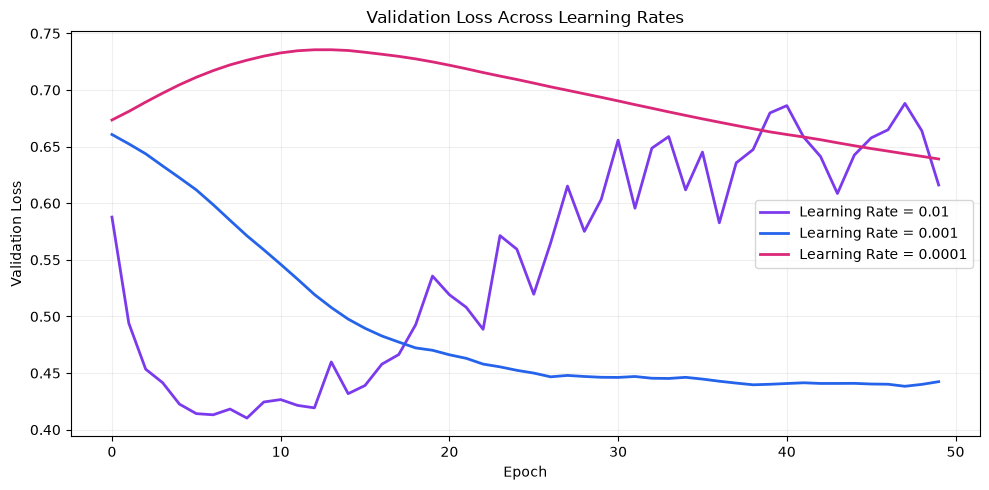

Selected learning rate: 0.01


In [10]:
best_learning_rate = float(
    learning_rate_results_df.loc[
        0,
        "Learning Rate"
    ]
)

plt.figure(figsize=(10, 5))

colors = {
    0.01: "#7C3AED",
    0.001: "#2563EB",
    0.0001: "#DB2777"
}

for learning_rate, history in learning_rate_histories.items():
    plt.plot(
        history.history["val_loss"],
        linewidth=2,
        color=colors[learning_rate],
        label=f"Learning Rate = {learning_rate}"
    )

plt.title("Validation Loss Across Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Selected learning rate:", best_learning_rate)

<div style="
    background:#F5F3FF;
    border-left:5px solid #7C3AED;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#6D28D9;margin:0 0 9px 0;">
Plot Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The learning rate of
<b style="color:#7C3AED;">0.01</b>
reduced validation loss quickly and achieved the lowest value of
<b style="color:#059669;">0.4103</b>
at epoch 9.

However, its validation loss increased and became unstable after this point,
showing that continued training could harm generalization.

The rate of 0.001 learned more gradually and remained stable, while 0.0001
was too slow within 50 epochs.

Therefore, 0.01 was selected, and EarlyStopping will later be used to keep
the model near its best epoch.
</p>

</div>

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#059669;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
TUNING PRIORITY 2
</p>

<h2 style="color:#047857;margin:0 0 9px 0;">
Network Size Experiments
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Three network widths will be compared while the selected learning rate,
dropout rate, batch size, and training data remain fixed.

This experiment tests whether the dataset benefits from a smaller or larger
learning capacity.
</p>

</div>

In [11]:
network_sizes = {
    "Small": (8, 4),
    "Original": (16, 8),
    "Large": (32, 16)
}

network_size_results = []
network_size_histories = {}

for size_name, hidden_units in network_sizes.items():
    print(
        f"Training {size_name} network: "
        f"{hidden_units[0]} → {hidden_units[1]}"
    )

    model = build_tuned_model(
        learning_rate=best_learning_rate,
        hidden_units=hidden_units,
        dropout_rate=0.30
    )

    history = model.fit(
        X_nn_train,
        y_nn_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    best_index = int(
        np.argmin(history.history["val_loss"])
    )

    network_size_results.append({
        "Network": size_name,
        "Hidden Layers":
            f"{hidden_units[0]} → {hidden_units[1]}",
        "Total Parameters": model.count_params(),
        "Best Epoch": best_index + 1,
        "Best Validation Loss":
            history.history["val_loss"][best_index],
        "Validation Accuracy":
            history.history["val_accuracy"][best_index]
    })

    network_size_histories[size_name] = history

network_size_results_df = pd.DataFrame(
    network_size_results
).sort_values(
    by="Best Validation Loss"
).reset_index(drop=True)

network_size_results_df.round(4)

Training Small network: 8 → 4
Training Original network: 16 → 8
Training Large network: 32 → 16


,Network,Hidden Layers,Total Parameters,Best Epoch,Best Validation Loss,Validation Accuracy
0,Large,32 → 16,1377,7,0.4023,0.8163
1,Original,16 → 8,561,9,0.4103,0.8435
2,Small,8 → 4,249,18,0.4308,0.8095


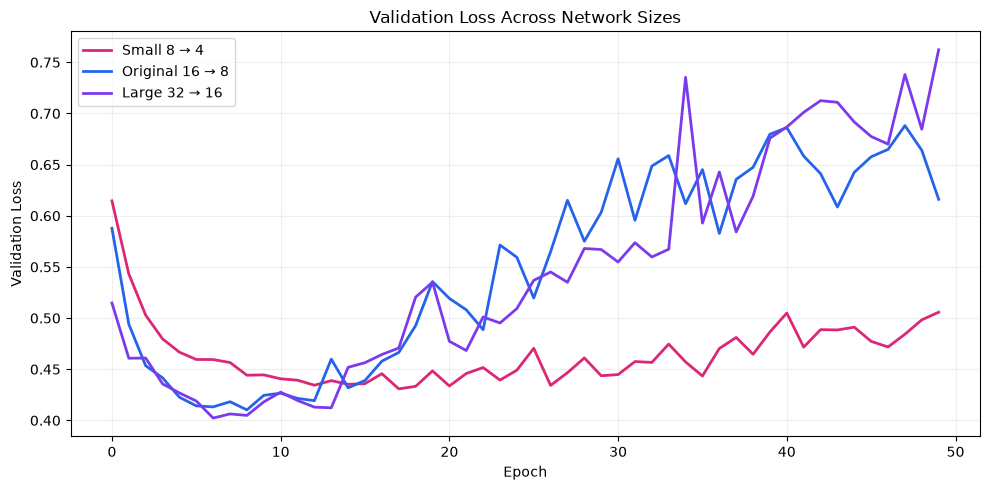

Selected network: Large
Selected hidden units: (32, 16)


In [12]:
best_network_name = (
    network_size_results_df.loc[0, "Network"]
)

best_hidden_units = network_sizes[
    best_network_name
]

plt.figure(figsize=(10, 5))

network_colors = {
    "Small": "#DB2777",
    "Original": "#2563EB",
    "Large": "#7C3AED"
}

for size_name, history in network_size_histories.items():
    plt.plot(
        history.history["val_loss"],
        linewidth=2,
        color=network_colors[size_name],
        label=(
            f"{size_name} "
            f"{network_sizes[size_name][0]} → "
            f"{network_sizes[size_name][1]}"
        )
    )

plt.title("Validation Loss Across Network Sizes")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Selected network:", best_network_name)
print("Selected hidden units:", best_hidden_units)

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#047857;margin:0 0 9px 0;">
Network Size Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The large network with
<b style="color:#7C3AED;">32 and 16 neurons</b>
achieved the lowest validation loss of
<b style="color:#059669;">0.4023</b>
at epoch 7.

The original network achieved higher validation accuracy at its best-loss epoch,
but the predefined tuning criterion was validation loss because it evaluates the
quality of the predicted probabilities.

Therefore, the 32 → 16 architecture will be carried forward.
Its early best epoch also suggests that a larger network can begin overfitting quickly,
making EarlyStopping important in the final training stage.
</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#DB2777;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
TUNING PRIORITY 3
</p>

<h2 style="color:#BE185D;margin:0 0 9px 0;">
Dropout Rate Experiments
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Different dropout rates will be tested while the selected learning rate,
network size, batch size, and training data remain fixed.

The goal is to reduce overfitting without removing so much learning capacity
that the model begins to underfit.
</p>

</div>

In [13]:
dropout_values = [
    0.10,
    0.20,
    0.30,
    0.40
]

dropout_results = []
dropout_histories = {}

for dropout_rate in dropout_values:
    print(f"Training with dropout rate = {dropout_rate}")

    model = build_tuned_model(
        learning_rate=best_learning_rate,
        hidden_units=best_hidden_units,
        dropout_rate=dropout_rate
    )

    history = model.fit(
        X_nn_train,
        y_nn_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    best_index = int(
        np.argmin(history.history["val_loss"])
    )

    dropout_results.append({
        "Dropout Rate": dropout_rate,
        "Best Epoch": best_index + 1,
        "Best Validation Loss":
            history.history["val_loss"][best_index],
        "Validation Accuracy":
            history.history["val_accuracy"][best_index]
    })

    dropout_histories[dropout_rate] = history

dropout_results_df = pd.DataFrame(
    dropout_results
).sort_values(
    by="Best Validation Loss"
).reset_index(drop=True)

dropout_results_df.round(4)

Training with dropout rate = 0.1
Training with dropout rate = 0.2
Training with dropout rate = 0.3
Training with dropout rate = 0.4


,Dropout Rate,Best Epoch,Best Validation Loss,Validation Accuracy
0,0.1,8,0.3900,0.8299
1,0.4,10,0.3966,0.8299
2,0.2,9,0.4014,0.8299
3,0.3,7,0.4023,0.8163


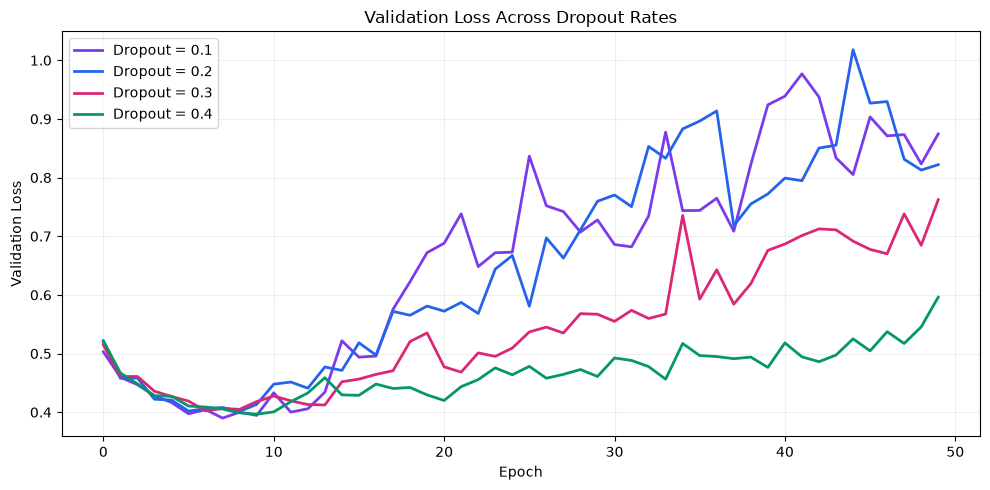

Selected dropout rate: 0.1


In [14]:
best_dropout_rate = float(
    dropout_results_df.loc[
        0,
        "Dropout Rate"
    ]
)

plt.figure(figsize=(10, 5))

dropout_colors = {
    0.10: "#7C3AED",
    0.20: "#2563EB",
    0.30: "#DB2777",
    0.40: "#059669"
}

for dropout_rate, history in dropout_histories.items():
    plt.plot(
        history.history["val_loss"],
        linewidth=2,
        color=dropout_colors[dropout_rate],
        label=f"Dropout = {dropout_rate}"
    )

plt.title("Validation Loss Across Dropout Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Selected dropout rate:", best_dropout_rate)

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#BE185D;margin:0 0 9px 0;">
Dropout Rate Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
A dropout rate of
<b style="color:#7C3AED;">0.10</b>
achieved the lowest validation loss of
<b style="color:#059669;">0.3900</b>
at epoch 8.

The rates of 0.20, 0.30, and 0.40 produced higher minimum validation losses.
This suggests that stronger dropout removed more learning capacity than the
current network required.

Therefore, a dropout rate of 0.10 will be carried forward to the batch-size experiment.
</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#EA580C;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
TUNING PRIORITY 4
</p>

<h2 style="color:#C2410C;margin:0 0 9px 0;">
Batch Size Experiments
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Batch sizes of 16, 32, and 64 will be compared while the selected learning rate,
network size, dropout rate, and training data remain fixed.

The experiment with the lowest validation loss will complete the tuned configuration.
</p>

</div>

In [15]:
batch_size_values = [
    16,
    32,
    64
]

batch_size_results = []
batch_size_histories = {}

for batch_size in batch_size_values:
    print(f"Training with batch size = {batch_size}")

    model = build_tuned_model(
        learning_rate=best_learning_rate,
        hidden_units=best_hidden_units,
        dropout_rate=best_dropout_rate
    )

    history = model.fit(
        X_nn_train,
        y_nn_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    best_index = int(
        np.argmin(history.history["val_loss"])
    )

    batch_size_results.append({
        "Batch Size": batch_size,
        "Best Epoch": best_index + 1,
        "Best Validation Loss":
            history.history["val_loss"][best_index],
        "Validation Accuracy":
            history.history["val_accuracy"][best_index]
    })

    batch_size_histories[batch_size] = history

batch_size_results_df = pd.DataFrame(
    batch_size_results
).sort_values(
    by="Best Validation Loss"
).reset_index(drop=True)

batch_size_results_df.round(4)

Training with batch size = 16
Training with batch size = 32
Training with batch size = 64


,Batch Size,Best Epoch,Best Validation Loss,Validation Accuracy
0,32,8,0.3900,0.8299
1,64,7,0.4226,0.8027
2,16,5,0.4333,0.8163


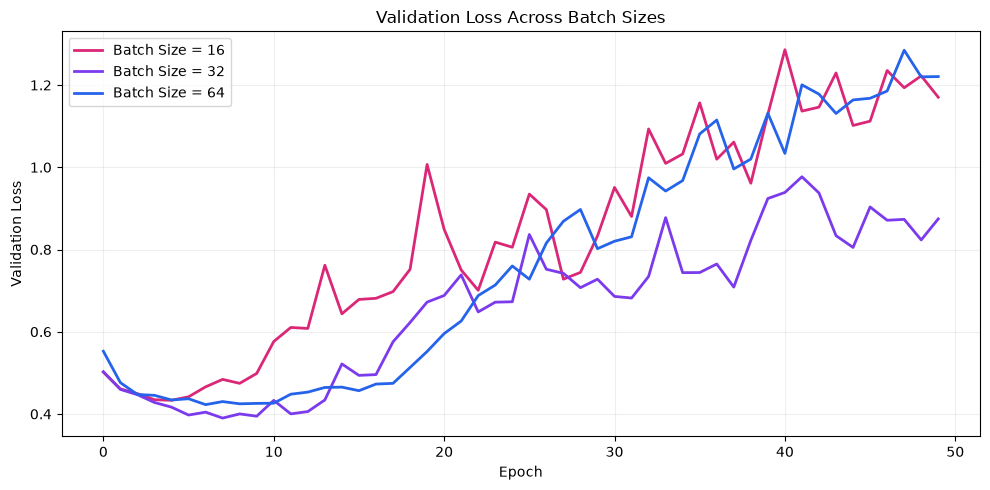

Selected batch size: 32


In [16]:
best_batch_size = int(
    batch_size_results_df.loc[
        0,
        "Batch Size"
    ]
)

plt.figure(figsize=(10, 5))

batch_colors = {
    16: "#DB2777",
    32: "#7C3AED",
    64: "#2563EB"
}

for batch_size, history in batch_size_histories.items():
    plt.plot(
        history.history["val_loss"],
        linewidth=2,
        color=batch_colors[batch_size],
        label=f"Batch Size = {batch_size}"
    )

plt.title("Validation Loss Across Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Selected batch size:", best_batch_size)

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#C2410C;margin:0 0 9px 0;">
Batch Size Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
A batch size of
<b style="color:#7C3AED;">32</b>
achieved the lowest validation loss of
<b style="color:#059669;">0.3900</b>
at epoch 8.

The smaller batch size of 16 and the larger batch size of 64 both produced
higher minimum validation losses.

Therefore, 32 was selected as the final batch size because it provided the
best balance for this dataset and model configuration.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #CBD5E1;
    border-left:5px solid #0F766E;
    border-radius:13px;
    padding:16px 19px;
    margin:22px 0 14px 0;
">

<h2 style="color:#0F766E;margin:0 0 8px 0;">
Tuning Experiment Summary
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The following table summarizes the values tested and the configuration selected
at each tuning stage. Each selected value was carried forward while only one
new hyperparameter was changed.
</p>

</div>

In [17]:
tuning_summary = pd.DataFrame([
    {
        "Tuning Stage": "Learning Rate",
        "Values Tested": "0.01, 0.001, 0.0001",
        "Selected Value": best_learning_rate,
        "Best Validation Loss":
            learning_rate_results_df.loc[
                0,
                "Best Validation Loss"
            ]
    },
    {
        "Tuning Stage": "Network Size",
        "Values Tested": "8→4, 16→8, 32→16",
        "Selected Value":
            f"{best_hidden_units[0]} → "
            f"{best_hidden_units[1]}",
        "Best Validation Loss":
            network_size_results_df.loc[
                0,
                "Best Validation Loss"
            ]
    },
    {
        "Tuning Stage": "Dropout Rate",
        "Values Tested": "0.10, 0.20, 0.30, 0.40",
        "Selected Value": best_dropout_rate,
        "Best Validation Loss":
            dropout_results_df.loc[
                0,
                "Best Validation Loss"
            ]
    },
    {
        "Tuning Stage": "Batch Size",
        "Values Tested": "16, 32, 64",
        "Selected Value": best_batch_size,
        "Best Validation Loss":
            batch_size_results_df.loc[
                0,
                "Best Validation Loss"
            ]
    }
])

tuning_summary.round(4)

,Tuning Stage,Values Tested,Selected Value,Best Validation Loss
0,Learning Rate,"0.01, 0.001, 0.0001",0.01,0.4103
1,Network Size,"8→4, 16→8, 32→16",32 → 16,0.4023
2,Dropout Rate,"0.10, 0.20, 0.30, 0.40",0.1,0.3900
3,Batch Size,"16, 32, 64",32,0.3900


<div style="
    background:#ECFEFF;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#0E7490;margin:0 0 9px 0;">
Tuning Conclusion
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The systematic tuning process reduced the best validation loss from
<b style="color:#BE123C;">0.4103</b>
in the first learning-rate stage to
<b style="color:#059669;">0.3900</b>
with the final configuration.

The selected configuration uses a learning rate of 0.01,
hidden layers of 32 and 16 neurons, a dropout rate of 0.10,
and a batch size of 32.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#0F766E 0%,#2563EB 55%,#6D28D9 100%);
    border-radius:16px;
    padding:21px 23px;
    margin:24px 0 16px 0;
">

<p style="color:#CCFBF1;font-weight:bold;letter-spacing:1.2px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 2
</p>

<h2 style="color:#FFFFFF;margin:0 0 9px 0;">
Train with EarlyStopping and ModelCheckpoint
</h2>

<p style="color:#E0F2FE;line-height:1.8;margin:0;">
The tuned network will be trained for a maximum of 100 epochs.
EarlyStopping will halt training when validation loss stops improving,
while ModelCheckpoint will save the best model observed during training.
</p>

</div>

In [18]:
tuned_model = build_tuned_model(
    learning_rate=best_learning_rate,
    hidden_units=best_hidden_units,
    dropout_rate=best_dropout_rate
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath="best_tuned_heart_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history_tuned = tuned_model.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=0
)

best_tuned_index = int(
    np.argmin(history_tuned.history["val_loss"])
)

best_tuned_epoch = best_tuned_index + 1
epochs_completed = len(
    history_tuned.history["loss"]
)
best_tuned_val_loss = (
    history_tuned.history["val_loss"][
        best_tuned_index
    ]
)

print("Maximum epochs allowed: 100")
print("Epochs actually completed:", epochs_completed)
print("Best epoch:", best_tuned_epoch)
print(
    "Best validation loss:",
    round(best_tuned_val_loss, 4)
)
print(
    "Checkpoint file:",
    "best_tuned_heart_model.keras"
)


Epoch 1: val_loss improved from None to 0.50288, saving model to best_tuned_heart_model.keras

Epoch 1: finished saving model to best_tuned_heart_model.keras

Epoch 2: val_loss improved from 0.50288 to 0.45968, saving model to best_tuned_heart_model.keras

Epoch 2: finished saving model to best_tuned_heart_model.keras

Epoch 3: val_loss improved from 0.45968 to 0.44688, saving model to best_tuned_heart_model.keras

Epoch 3: finished saving model to best_tuned_heart_model.keras

Epoch 4: val_loss improved from 0.44688 to 0.42793, saving model to best_tuned_heart_model.keras

Epoch 4: finished saving model to best_tuned_heart_model.keras

Epoch 5: val_loss improved from 0.42793 to 0.41658, saving model to best_tuned_heart_model.keras

Epoch 5: finished saving model to best_tuned_heart_model.keras

Epoch 6: val_loss improved from 0.41658 to 0.39736, saving model to best_tuned_heart_model.keras

Epoch 6: finished saving model to best_tuned_heart_model.keras

Epoch 7: val_loss did not impr

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#047857;margin:0 0 9px 0;">
Callback Observation
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The tuned model was allowed to train for a maximum of 100 epochs,
but EarlyStopping halted training after
<b style="color:#7C3AED;">13 epochs</b>.

The lowest validation loss was
<b style="color:#059669;">0.3900</b>
at epoch
<b style="color:#2563EB;">8</b>.

After five consecutive epochs without improvement, training stopped and
the weights from epoch 8 were restored. ModelCheckpoint also saved this
best version as <b>best_tuned_heart_model.keras</b>.
</p>

</div>

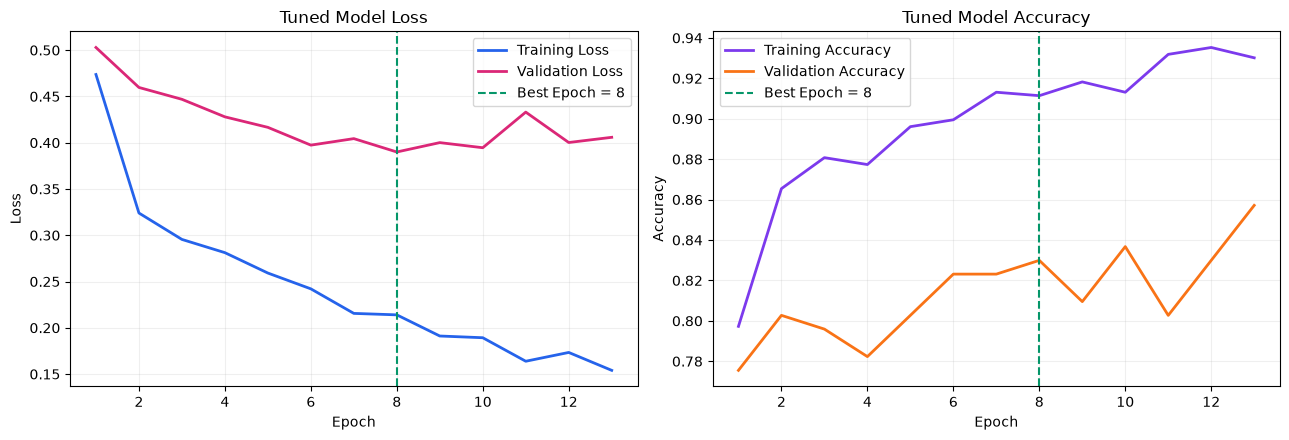

In [19]:

tuned_epochs = range(
    1,
    epochs_completed + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# Loss curves
axes[0].plot(
    tuned_epochs,
    history_tuned.history["loss"],
    color="#2563EB",
    linewidth=2,
    label="Training Loss"
)

axes[0].plot(
    tuned_epochs,
    history_tuned.history["val_loss"],
    color="#DB2777",
    linewidth=2,
    label="Validation Loss"
)

axes[0].axvline(
    best_tuned_epoch,
    color="#059669",
    linestyle="--",
    label=f"Best Epoch = {best_tuned_epoch}"
)

axes[0].set_title("Tuned Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Accuracy curves
axes[1].plot(
    tuned_epochs,
    history_tuned.history["accuracy"],
    color="#7C3AED",
    linewidth=2,
    label="Training Accuracy"
)

axes[1].plot(
    tuned_epochs,
    history_tuned.history["val_accuracy"],
    color="#F97316",
    linewidth=2,
    label="Validation Accuracy"
)

axes[1].axvline(
    best_tuned_epoch,
    color="#059669",
    linestyle="--",
    label=f"Best Epoch = {best_tuned_epoch}"
)

axes[1].set_title("Tuned Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

<div style="
    background:#F5F3FF;
    border-left:5px solid #7C3AED;
    border-radius:12px;
    padding:16px 19px;
    margin:14px 0 21px 0;
">

<h3 style="color:#6D28D9;margin:0 0 9px 0;">
Training Curve Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
Training loss continued to decrease and training accuracy continued to increase
throughout the 13 completed epochs.

Validation loss improved until it reached its minimum at
<b style="color:#059669;">epoch 8</b>,
then began to fluctuate while the gap between training and validation performance widened.

This indicates that continued training was beginning to increase overfitting.
EarlyStopping prevented unnecessary epochs and restored the model weights from
the point with the strongest validation loss.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#0F172A 0%,#1E3A8A 55%,#0E7490 100%);
    border-radius:16px;
    padding:21px 23px;
    margin:24px 0 16px 0;
">

<p style="color:#BAE6FD;font-weight:bold;letter-spacing:1.2px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 3
</p>

<h2 style="color:#FFFFFF;margin:0 0 9px 0;">
Evaluate the Best Saved Model
</h2>

<p style="color:#E0F2FE;line-height:1.8;margin:0;">
The best checkpoint will now be loaded and evaluated once on the untouched
test set. This provides the final unbiased performance estimate for the tuned model.
</p>

</div>

In [20]:
best_tuned_model = load_model(
    "best_tuned_heart_model.keras"
)

tuned_test_loss, tuned_test_accuracy = (
    best_tuned_model.evaluate(
        X_test_processed,
        y_test_nn,
        verbose=0
    )
)

tuned_probabilities = (
    best_tuned_model.predict(
        X_test_processed,
        verbose=0
    ).ravel()
)

tuned_predictions = (
    tuned_probabilities >= 0.50
).astype(int)

tuned_precision = precision_score(
    y_test_nn,
    tuned_predictions
)

tuned_recall = recall_score(
    y_test_nn,
    tuned_predictions
)

tuned_f1 = f1_score(
    y_test_nn,
    tuned_predictions
)

tuned_roc_auc = roc_auc_score(
    y_test_nn,
    tuned_probabilities
)

print("Tuned Model Test Results")
print("------------------------")
print("Test Loss:", round(tuned_test_loss, 4))
print("Accuracy:", round(tuned_test_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1-score:", round(tuned_f1, 4))
print("ROC-AUC:", round(tuned_roc_auc, 4))

Tuned Model Test Results
------------------------
Test Loss: 0.3585
Accuracy: 0.8587
Precision: 0.8958
Recall: 0.8431
F1-score: 0.8687
ROC-AUC: 0.9235


<div style="
    background:#ECFEFF;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<h2 style="color:#0E7490;margin:0 0 9px 0;">
Final Model Comparison
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The tuned neural network will be compared with the Day 1 Logistic Regression
baseline and the two neural networks evaluated on Day 4.

All models were evaluated using the same untouched test set.
</p>

</div>

In [21]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression Baseline",
        "Accuracy": 0.886,
        "Precision": 0.886,
        "Recall": 0.912,
        "F1-score": 0.899
    },
    {
        "Model": "Basic Neural Network",
        "Accuracy": 0.859,
        "Precision": 0.865,
        "Recall": 0.882,
        "F1-score": 0.874
    },
    {
        "Model": "Regularized Neural Network",
        "Accuracy": 0.875,
        "Precision": 0.925,
        "Recall": 0.843,
        "F1-score": 0.882
    },
    {
        "Model": "Tuned Neural Network",
        "Accuracy": tuned_test_accuracy,
        "Precision": tuned_precision,
        "Recall": tuned_recall,
        "F1-score": tuned_f1
    }
])

final_comparison.iloc[:, 1:] = (
    final_comparison.iloc[:, 1:].round(3)
)

final_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression Baseline,0.886,0.886,0.912,0.899
1,Basic Neural Network,0.859,0.865,0.882,0.874
2,Regularized Neural Network,0.875,0.925,0.843,0.882
3,Tuned Neural Network,0.859,0.896,0.843,0.869


<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:16px 19px;
    margin:14px 0 21px 0;
">

<h3 style="color:#C2410C;margin:0 0 9px 0;">
Final Evaluation Observation
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The tuned neural network achieved an F1-score of
<b style="color:#7C3AED;">0.869</b>
and a ROC-AUC of
<b style="color:#059669;">0.924</b>.

Although tuning reduced validation loss, it did not improve test-set F1-score.
The regularized Day 4 network remained the strongest neural network with an
F1-score of 0.882, while Logistic Regression remained the strongest overall
model with an F1-score of
<b style="color:#BE123C;">0.899</b>
and the highest recall of 0.912.

This result shows that better validation loss does not always guarantee better
test performance, especially on a relatively small tabular dataset.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:5px solid #7C3AED;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<h2 style="color:#6D28D9;margin:0 0 9px 0;">
Sprint Evidence - F1 and Recall Comparison
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
F1-score summarizes the balance between precision and recall, while recall
shows how many true heart-disease cases were successfully detected.
</p>

</div>

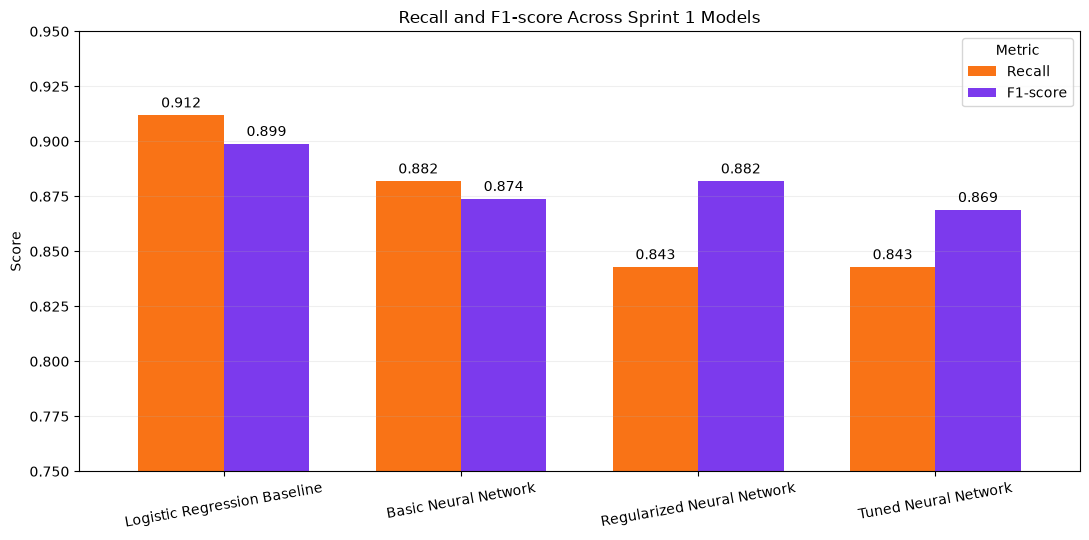

In [22]:
comparison_plot = (
    final_comparison
    .set_index("Model")[
        ["Recall", "F1-score"]
    ]
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 5.5),
    color=["#F97316", "#7C3AED"],
    width=0.72
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

ax.set_title(
    "Recall and F1-score Across Sprint 1 Models"
)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0.75, 0.95)
ax.tick_params(
    axis="x",
    rotation=10
)
ax.legend(title="Metric")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

<div style="
    background:#F8FAFC;
    border-left:5px solid #64748B;
    border-radius:12px;
    padding:15px 18px;
    margin:14px 0 21px 0;
">

<h3 style="color:#334155;margin:0 0 9px 0;">
Metric Comparison Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
Logistic Regression achieved both the highest recall of
<b style="color:#F97316;">0.912</b>
and the highest F1-score of
<b style="color:#7C3AED;">0.899</b>.

The tuned neural network achieved lower recall and F1-score than both the
baseline and the regularized network.

For this small structured dataset, systematic neural-network tuning did not
replace the simpler Logistic Regression model as the strongest final choice.
</p>

</div>

<div style="
    background:#FFF1F2;
    border-left:5px solid #E11D48;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<h2 style="color:#BE123C;margin:0 0 9px 0;">
Tuned Model Confusion Matrix
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The confusion matrix separates correct predictions from false alarms and
missed heart-disease cases, providing a clearer clinical view of model errors.
</p>

</div>

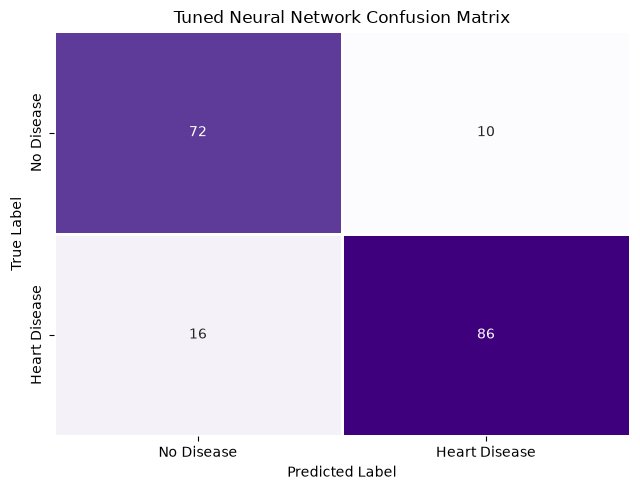

True Negatives: 72
False Positives: 10
False Negatives: 16
True Positives: 86


In [23]:
tuned_confusion_matrix = confusion_matrix(
    y_test_nn,
    tuned_predictions
)

plt.figure(figsize=(6.5, 5))

sns.heatmap(
    tuned_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    linewidths=1,
    linecolor="white",
    xticklabels=[
        "No Disease",
        "Heart Disease"
    ],
    yticklabels=[
        "No Disease",
        "Heart Disease"
    ]
)

plt.title("Tuned Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = (
    tuned_confusion_matrix.ravel()
)

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

<div style="
    background:#FFF1F2;
    border-left:5px solid #E11D48;
    border-radius:12px;
    padding:16px 19px;
    margin:14px 0 21px 0;
">

<h3 style="color:#BE123C;margin:0 0 9px 0;">
Confusion Matrix Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The tuned neural network correctly identified
<b style="color:#059669;">86 heart-disease cases</b>
and correctly classified
<b style="color:#2563EB;">72 non-disease cases</b>.

It produced 10 false positives and
<b style="color:#BE123C;">16 false negatives</b>.

The false negatives represent patients with heart disease who were missed by
the model. This explains the tuned model's lower recall of 0.843 and is an
important limitation in a health-risk classification task.
</p>

</div>

<div style="
    background:#F0FDFA;
    border-left:5px solid #0F766E;
    border-radius:12px;
    padding:17px 20px;
    margin:22px 0 14px 0;
">

<p style="color:#0F766E;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
FINAL TUNED ARCHITECTURE
</p>

<h2 style="color:#134E4A;margin:0 0 12px 0;">
Selected Neural Network Configuration
</h2>

<div style="
    background:#0F172A;
    border-radius:11px;
    padding:15px;
    text-align:center;
    margin:12px 0;
">

<p style="color:#FFFFFF;font-size:16px;font-weight:bold;margin:0;line-height:2;">
21 Inputs
<span style="color:#38BDF8;"> → </span>
Dense 32 · ReLU
<span style="color:#38BDF8;"> → </span>
Batch Normalization
<span style="color:#38BDF8;"> → </span>
Dropout 10%
<br>
<span style="color:#38BDF8;"> → </span>
Dense 16 · ReLU
<span style="color:#38BDF8;"> → </span>
1 Sigmoid Output
</p>

</div>

<table style="width:100%;border-collapse:collapse;color:#475569;line-height:1.7;">
<tr style="background:#F8FAFC;">
<td style="padding:9px;border:1px solid #CBD5E1;"><b>Learning Rate</b></td>
<td style="padding:9px;border:1px solid #CBD5E1;">0.01</td>
</tr>
<tr>
<td style="padding:9px;border:1px solid #CBD5E1;"><b>Batch Size</b></td>
<td style="padding:9px;border:1px solid #CBD5E1;">32</td>
</tr>
<tr style="background:#F8FAFC;">
<td style="padding:9px;border:1px solid #CBD5E1;"><b>Best Epoch</b></td>
<td style="padding:9px;border:1px solid #CBD5E1;">8</td>
</tr>
<tr>
<td style="padding:9px;border:1px solid #CBD5E1;"><b>Best Validation Loss</b></td>
<td style="padding:9px;border:1px solid #CBD5E1;">0.3900</td>
</tr>
</table>

</div>

In [24]:
best_tuned_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,005 (15.65 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 2,628 (10.27 KB)

<div style="
    background:linear-gradient(135deg,#312E81 0%,#6D28D9 55%,#BE185D 100%);
    border-radius:16px;
    padding:22px 24px;
    margin:25px 0 16px 0;
">

<p style="color:#FBCFE8;font-weight:bold;letter-spacing:1.2px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 4
</p>

<h2 style="color:#FFFFFF;margin:0 0 9px 0;">
Sprint 1 Review
</h2>

<p style="color:#EDE9FE;line-height:1.8;margin:0;">
Sprint 1 established a classical baseline, explained the neural-network
training process, built and regularized Keras models, and completed a
systematic tuning and evaluation cycle.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #CBD5E1;
    border-radius:14px;
    padding:18px 20px;
    margin:16px 0;
">

<h3 style="color:#0F766E;margin:0 0 13px 0;">
Sprint Evidence Summary
</h3>

<table style="width:100%;border-collapse:collapse;color:#475569;line-height:1.7;">
<tr style="background:#F8FAFC;">
<th style="padding:10px;border:1px solid #CBD5E1;text-align:left;">Sprint Stage</th>
<th style="padding:10px;border:1px solid #CBD5E1;text-align:left;">Evidence</th>
</tr>

<tr>
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Baseline</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
Logistic Regression achieved F1 = 0.899 and Recall = 0.912.
</td>
</tr>

<tr style="background:#F8FAFC;">
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Basic Network</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
The first Keras network achieved F1 = 0.874.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Regularization</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
Batch Normalization and 30% Dropout produced F1 = 0.882.
</td>
</tr>

<tr style="background:#F8FAFC;">
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Tuning</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
One variable was changed at a time. The selected configuration was
LR = 0.01, layers = 32 → 16, Dropout = 0.10, and Batch Size = 32.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Callbacks</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
EarlyStopping halted training at epoch 13 and restored epoch 8.
ModelCheckpoint saved the best model.
</td>
</tr>

<tr style="background:#F8FAFC;">
<td style="padding:10px;border:1px solid #CBD5E1;"><b>Final Evaluation</b></td>
<td style="padding:10px;border:1px solid #CBD5E1;">
The tuned network achieved F1 = 0.869, Recall = 0.843,
and ROC-AUC = 0.924.
</td>
</tr>
</table>

</div>

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:16px 19px;
    margin:16px 0 22px 0;
">

<h3 style="color:#047857;margin:0 0 9px 0;">
Sprint Review Conclusion
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
Sprint 1 completed the full path from baseline development to neural-network
tuning and final evaluation.

The tuned network produced a strong ROC-AUC, but its threshold-based F1-score
and recall did not surpass the previous models.

Logistic Regression remained the strongest overall choice for this relatively
small structured dataset, demonstrating that a more complex model is not
automatically the most effective one.
</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #DB2777;
    border-radius:12px;
    padding:17px 20px;
    margin:22px 0;
">

<h2 style="color:#BE185D;margin:0 0 12px 0;">
Sprint 1 Retrospective
</h2>

<p style="color:#475569;line-height:1.85;">
<b style="color:#059669;">What went well:</b><br>
The baseline, neural networks, tuning experiments, callbacks, and final
evaluation were completed using a consistent workflow.
</p>

<p style="color:#475569;line-height:1.85;">
<b style="color:#F97316;">What could improve:</b><br>
The lower validation loss did not transfer to better test performance,
showing the importance of tracking generalization rather than relying on
one validation result.
</p>

<p style="color:#475569;line-height:1.85;margin-bottom:0;">
<b style="color:#7C3AED;">Concrete change for Sprint 2:</b><br>
I will record every experiment configuration and result immediately in MLflow
to make comparisons clearer and more reproducible.
</p>

</div>

<div style="
    background:#FFFBEB;
    border-left:5px solid #F59E0B;
    border-radius:12px;
    padding:17px 20px;
    margin:22px 0 14px 0;
">

<h2 style="color:#B45309;margin:0 0 9px 0;">
Sprint 1 Acceptance Criteria
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The checklist separates completed technical work from the final repository
and mentor-review tasks required before Sprint 1 can be officially closed.
</p>

</div>

- [x] The same dataset, preprocessing, and test split were reused.
- [x] One hyperparameter was changed at a time.
- [x] Every tuning experiment was recorded and compared using validation loss.
- [x] EarlyStopping restored the best model weights.
- [x] ModelCheckpoint saved the best model.
- [x] Loss curves and a final metric table were included.
- [x] The tuned model was compared with the Logistic Regression baseline.
- [x] Results and observations were documented in Markdown.
- [ ] Restart the kernel and run the complete notebook without errors.
- [ ] Commit Day 5 work to the correct Git branch.
- [ ] Obtain mentor approval and merge the pull request.